## Customer Churn Prediction

### Objective
Analyze telecom customer behavior and identify patterns associated with customer churn

In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [8]:
#Import libraries

#Data manipulation
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [9]:
#Load the dataset
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Business Problem

Customer churn is one of the biggest challenges in the telecom industry.

The goal of this project is to predict whether a customer is likely to cancel their subscription based on demographic, account, and service usage information.

By identifying customers at risk of churn, telecom companies can proactively implement retention strategies and reduce revenue loss.

In [10]:
#Initial data exploration
df.shape

(7043, 21)

In [11]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
#summary statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
#check for missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
#Data Cleaning
df['TotalCharges'].head()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [15]:
#Analyze churn distribution
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [16]:
# percentage churn distribution
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


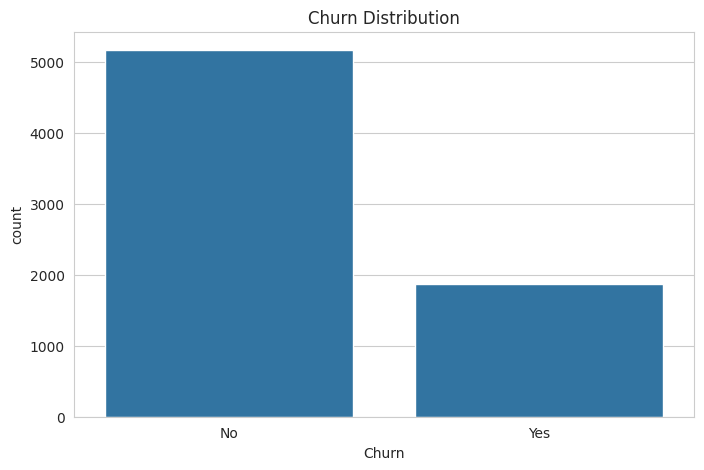

In [17]:
#Visualize the churn
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

The dataset is imbalanced, with significantly more non-churn customers than churn customers.

This means accuracy alone may not be a reliable evaluation metric during modeling.

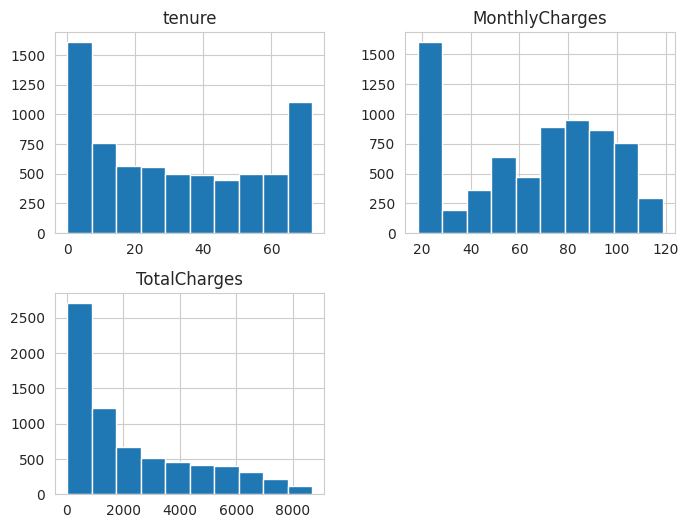

In [18]:
#Numerical feature analysis
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(8,6))
plt.show()

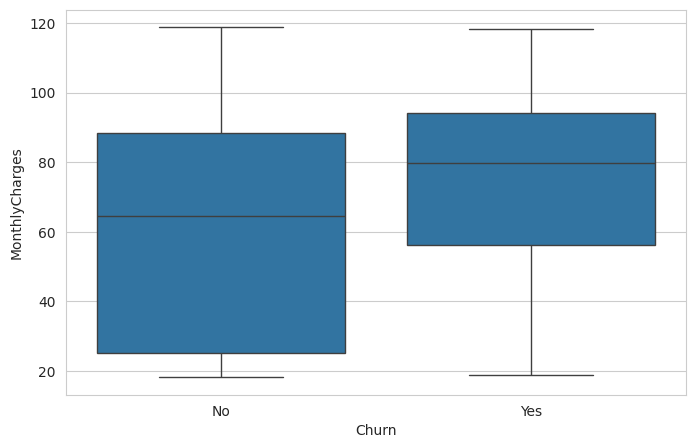

In [19]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df )
plt.show()

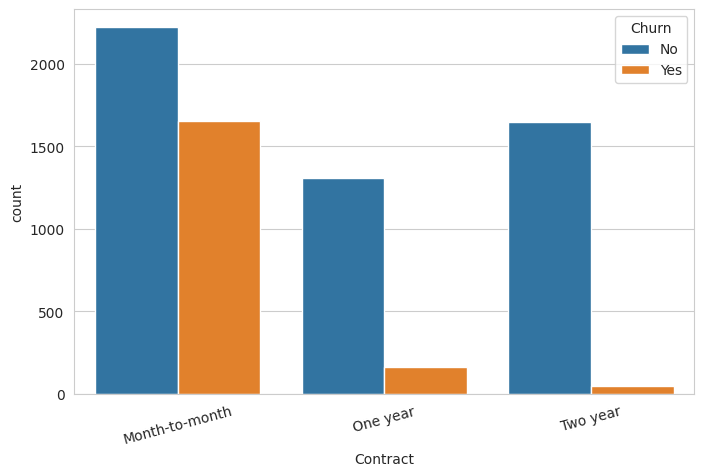

In [20]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.show()

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

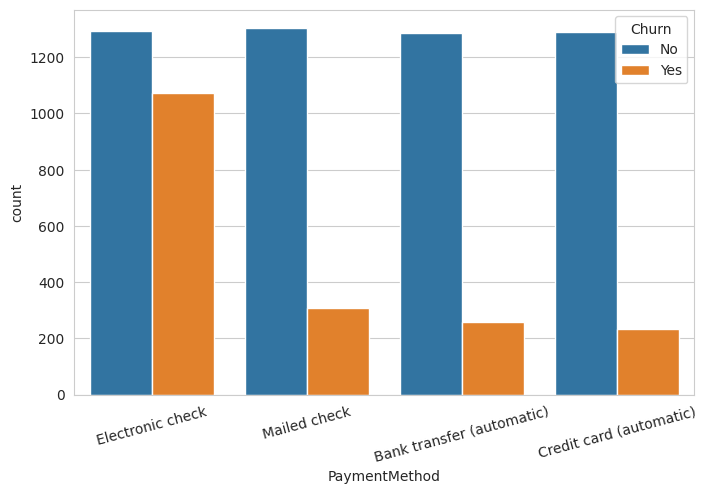

In [21]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=15)

([0, 1, 2], [Text(0, 0, 'DSL'), Text(1, 0, 'Fiber optic'), Text(2, 0, 'No')])

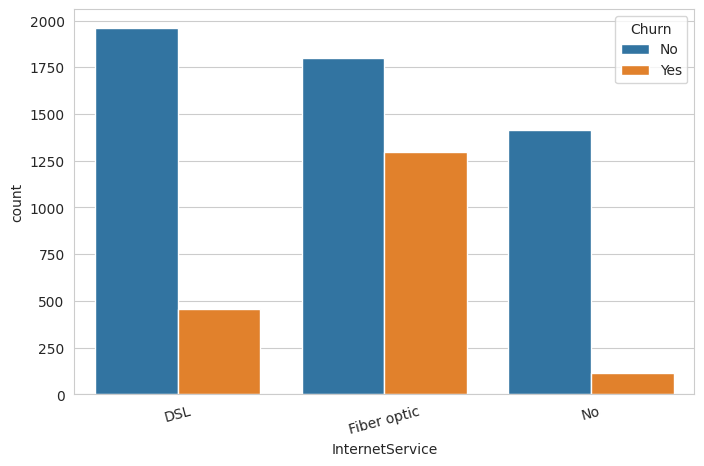

In [22]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.xticks(rotation=15)

([0, 1, 2],
 [Text(0, 0, 'No'), Text(1, 0, 'Yes'), Text(2, 0, 'No internet service')])

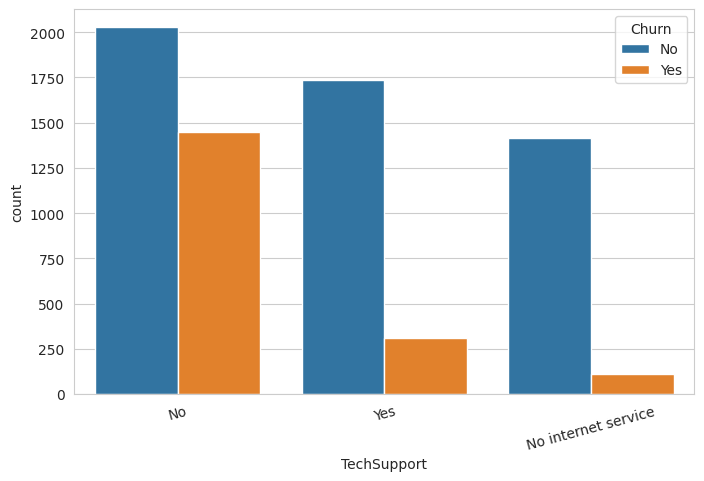

In [23]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.xticks(rotation=15)

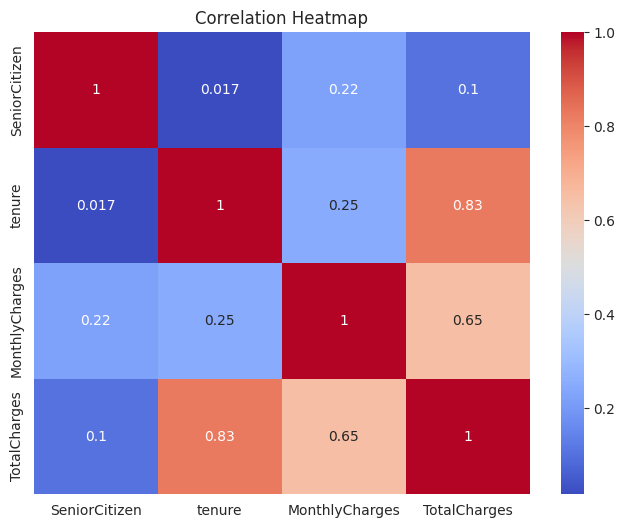

In [24]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Key Insights from EDA

1. Customers with month-to-month contracts exhibit significantly higher churn rates.

2. Customers with shorter tenure are more likely to churn.

3. Higher monthly charges are associated with increased churn probability.

4. Customers lacking tech support and online security services show elevated churn behavior.

5. Electronic check users demonstrate higher churn rates compared to automatic payment users.

# Next Steps

1. Handle missing values in TotalCharges
2. Encode categorical variables
3. Address class imbalance using SMOTE or class weights
4. Train classification models
5. Evaluate using Recall, F1-score, and ROC-AUC

In [25]:
#Convert churn to numeric
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [26]:
#Separate X and y
X = df.drop(['customerID', 'Churn'], axis = 1)
y = df['Churn']

In [27]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [28]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [30]:
from sklearn.impute import SimpleImputer

#Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [31]:
#Handle class imbalance
smote = SMOTE(random_state=42)

SMOTE synthetically generates minority-class examples to improve the model’s ability to learn churn patterns.

# Baseline models
1. Logistic Regression
2. Random Forest
3. SVM
4. XGBoost

In [32]:
#1. Logistic regression
lr_pipeline = ImbPipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', LogisticRegression(class_weight='balanced', random_state=42))
    ]
)

In [33]:
#2. Random Forest
rf_pipeline = ImbPipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]
)

In [34]:
#3. SVM
svm_pipeline = ImbPipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', SVC(class_weight='balanced', probability=True, random_state=42))
    ]
)
#

In [35]:
#4. XGBoost
xgb_pipeline = ImbPipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', XGBClassifier(scale_pos_weight=1, random_state=42))
    ]
)

In [36]:
#Store the models in a dictionary
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'SVM': svm_pipeline,
    'XGBoost': xgb_pipeline
}

In [37]:
results = []

for name, model in  models.items():
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1] # Select probabilities of the positive class

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_prob)

  results.append(
      {
          'Model': name,
          'Accuracy': accuracy,
          'Precision': precision,
          'Recall': recall,
          'F1-Score': f1,
          'ROC-AUC': roc_auc
      }
  )

  print(f'\n{name}')
  print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.54      0.55       374

    accuracy                           0.76      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409


SVM
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.75

In [38]:
#results dataframe
results_df = pd.DataFrame(results)
results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.738112,0.504244,0.794118,0.616822,0.839911
2,SVM,0.754436,0.527344,0.721925,0.609481,0.821284
3,XGBoost,0.780696,0.583120,0.609626,0.596078,0.819706
1,Random Forest,0.763662,0.556474,0.540107,0.548168,0.810806


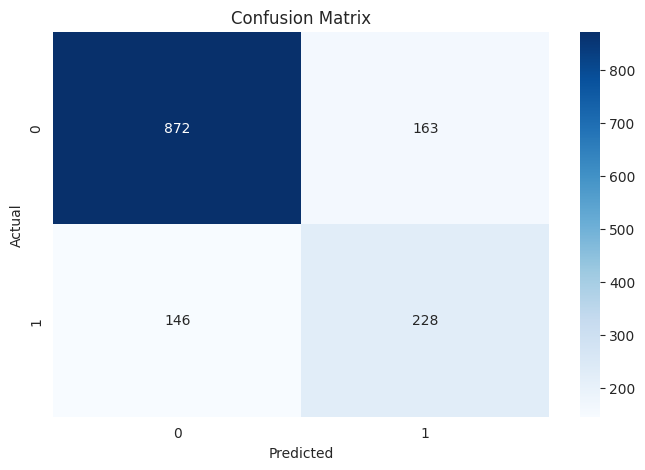

In [39]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<Figure size 1000x700 with 0 Axes>

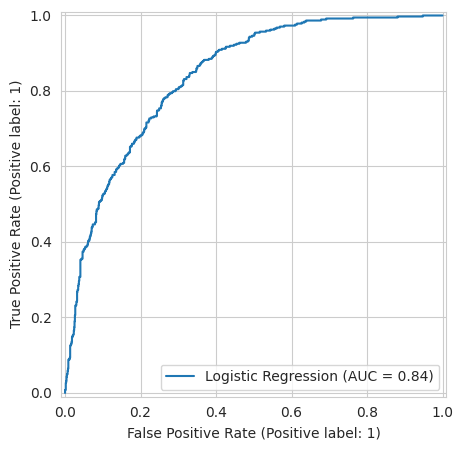

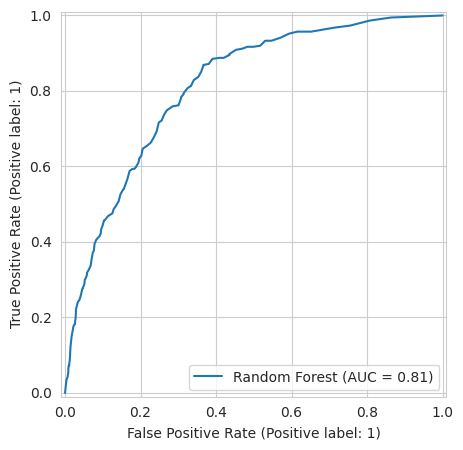

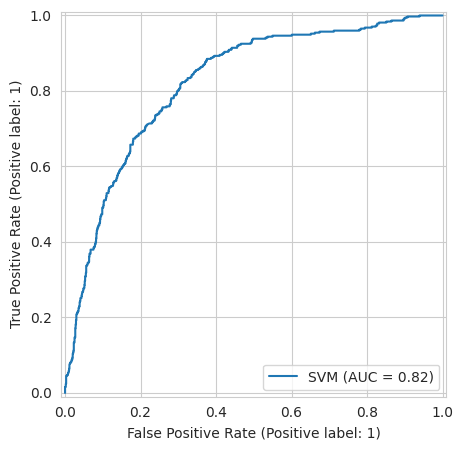

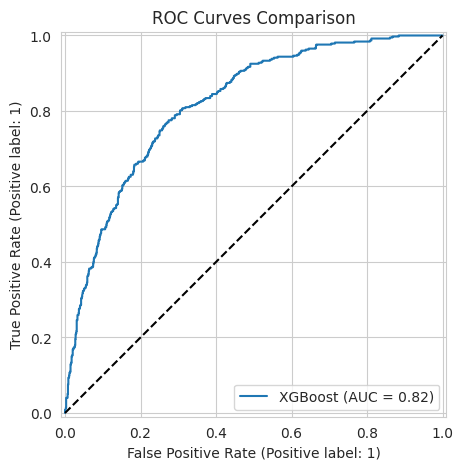

In [40]:
plt.figure(figsize=(10,7))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curves Comparison')
plt.show()

In [41]:
feature_importance = rf_pipeline.named_steps['model'].feature_importances_

# Key Modeling Insights

1. Class imbalance significantly affected model performance, reinforcing the importance of SMOTE and recall-focused evaluation.

2. XGBoost achieved the best balance between recall and ROC-AUC performance.

3. Logistic Regression provided strong interpretability while maintaining competitive recall.

4. ROC analysis demonstrated that ensemble models outperformed linear models in separating churners from non-churners.

# Next Steps

1. Tune the best-performing model using RandomizedSearchCV
2. Optimize decision threshold for higher recall
3. Apply SHAP explainability
4. Develop business recommendations by customer segment

# Customer Churn Prediction — Model Tuning, Explainability & Business Recommendations

In [42]:
#Select best baseline model
best_model = xgb_pipeline

In [43]:
#Hyperparameter tuning with randomizedsearch CV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint, uniform

xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

{'model__colsample_bytree': np.float64(0.8446612641953124), 'model__learning_rate': np.float64(0.012119891565915222), 'model__max_depth': 3, 'model__n_estimators': 148, 'model__subsample': np.float64(0.8099098641033556)}
0.7832775919732442


In [44]:
#evaluate the tuned model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8388708052390917


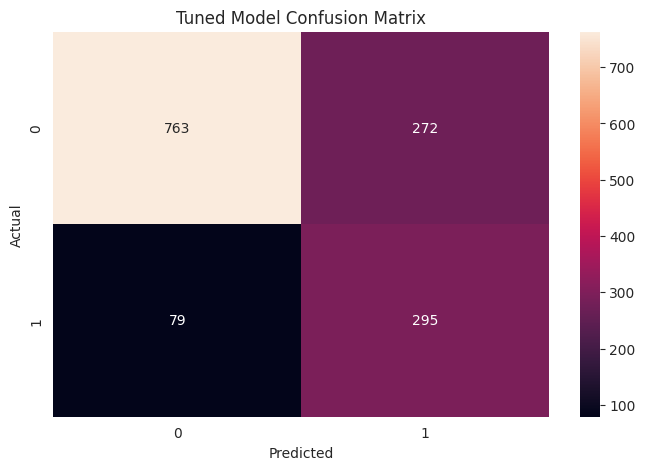

In [45]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Tuned Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
#decision threshold tuning. default is 0.5.
#For churn prediction, test lower threshold like 0.3

threshold = 0.3
y_pred_tuned = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_tuned))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_tuned))
#


              precision    recall  f1-score   support

           0       0.96      0.51      0.66      1035
           1       0.41      0.94      0.57       374

    accuracy                           0.62      1409
   macro avg       0.68      0.72      0.62      1409
weighted avg       0.81      0.62      0.64      1409

ROC-AUC: 0.7245821385207576


In [47]:
#compare thresholds
thresholds = [0.2, 0.3, 0.4, 0.5]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1 Score': f1_score(y_test, y_pred_t)
    })

pd.DataFrame(threshold_results)

,Threshold,Precision,Recall,F1 Score
0,0.2,0.366098,0.975936,0.532458
1,0.3,0.408092,0.943850,0.569814
2,0.4,0.454161,0.860963,0.594645
3,0.5,0.520282,0.788770,0.626993


Lowering the threshold from 0.5 to 0.3 increased recall, meaning the model identifies more potential churners. However, this also reduces precision, meaning more customers may receive unnecessary retention offers.

In [48]:
import shap

In [49]:
preprocessor = best_model.named_steps['preprocessor']
xgb_model = best_model.named_steps['model']

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [50]:
feature_names = preprocessor.get_feature_names_out()

In [51]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

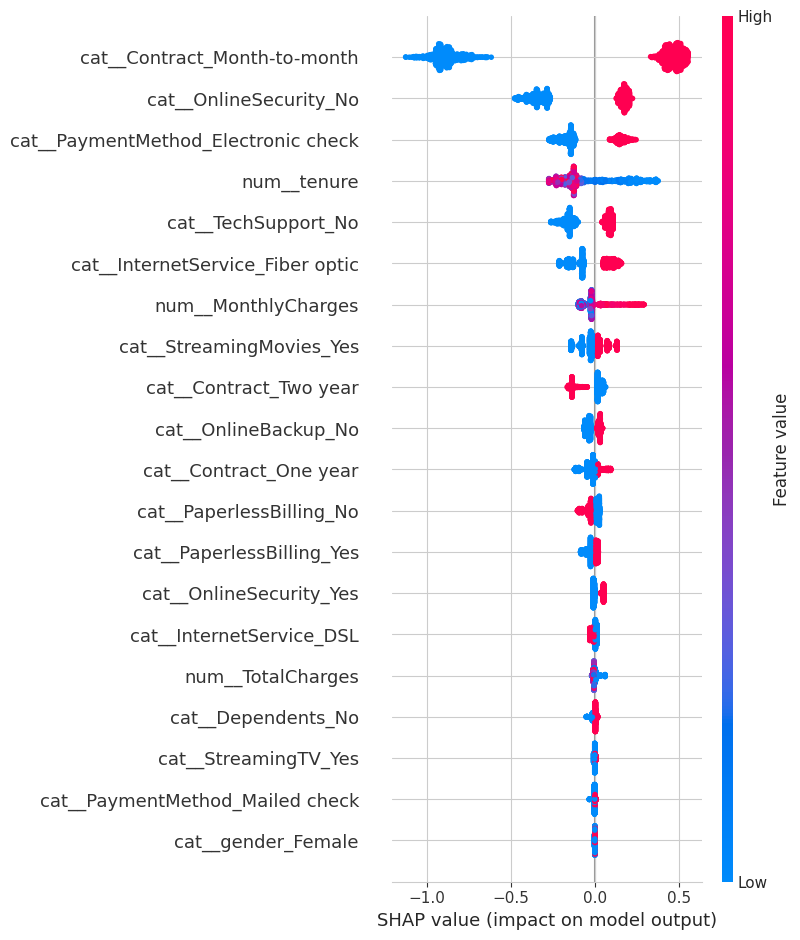

In [52]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

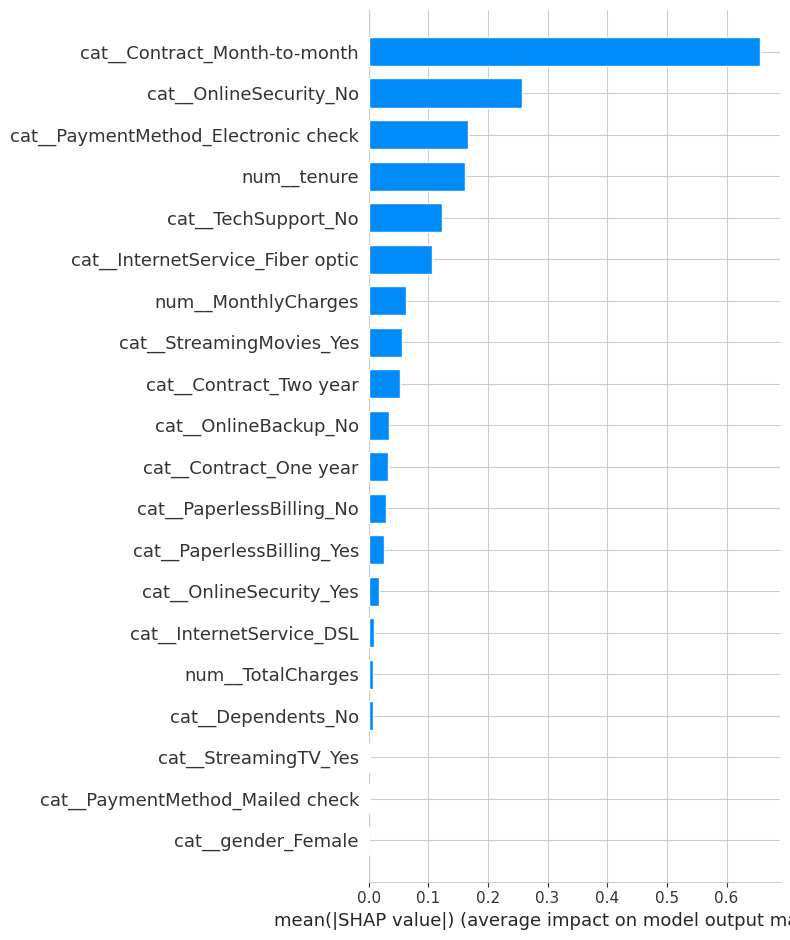

In [53]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar'
)

SHAP analysis showed that churn risk is strongly influenced by contract type, tenure, monthly charges, internet service type, and support services.

Customers on month-to-month contracts and customers with shorter tenure are more likely to churn, while long-tenure customers and customers on longer contracts tend to be more stable.

#Business Recommendations

## 1. Month-to-month customers

Offer discounts or benefits for customers who upgrade to one-year or two-year contracts.

## 2. New customers with low tenure

Create onboarding campaigns during the first 3–6 months to reduce early churn.

## 3. High monthly charges

Provide personalized retention offers, loyalty discounts, or plan reviews.

## 4. Customers without tech support

Bundle tech support or security services into retention packages.

## 5. Electronic check users

Encourage automatic payment methods by offering small incentives.